Analyze time-series fluorescence data from PURE (Protein synthesis Using Recombinant Elements) experiments. 

## Setup 

In [1]:
%load_ext autoreload
%autoreload 2
    
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
from cdk.analysis.cytosol import platereader as pr

# Set up plotting
pr.plot_setup()

## Load Data

In [5]:
# Specify file paths
data_file = "20260521-140552-cytation3-pure-timecourse-gfp-Cytosol-Lifetime-R2-biotek-cdk.txt"
platemap_file = "20260521-platemap-Cytosol-Lifetime-R2.csv"


# Load data
data, platemap = pr.load_platereader_data(
    data_file=data_file,
    platemap_file=platemap_file,
    platereader="biotek-cdk"  # Options: "cytation", "envision", "biotek-cdk"
)

# Checkout first few rows
data.head()

,Time,Well,Data,Row,Column,Read,Clock Time,Reader,Date,Experiment Name,...,tRNA Vol (uL),DNA Vol (uL),RNase Inhib Vol (uL),CP Vol (uL),PPK Vol (uL),polyP Vol (uL),Mg-Ace Vol (uL),PEG Vol (uL),Water vol (uL),Rxn Volume (uL)
0,0 days 00:00:00,B2,47,B,2,GFP-F-G35,2026-05-21 14:31:08,Cytation3,20260506,Cytosol-Lifetime-Test,...,1.00,0.50,0.50,NaN,NaN,NaN,NaN,NaN,2.00,10
1,0 days 00:05:00,B2,88,B,2,GFP-F-G35,2026-05-21 14:36:08,Cytation3,20260506,Cytosol-Lifetime-Test,...,1.00,0.50,0.50,NaN,NaN,NaN,NaN,NaN,2.00,10
2,0 days 00:10:00,B2,1556,B,2,GFP-F-G35,2026-05-21 14:41:08,Cytation3,20260506,Cytosol-Lifetime-Test,...,1.00,0.50,0.50,NaN,NaN,NaN,NaN,NaN,2.00,10
3,0 days 00:15:00,B2,5439,B,2,GFP-F-G35,2026-05-21 14:46:08,Cytation3,20260506,Cytosol-Lifetime-Test,...,1.00,0.50,0.50,NaN,NaN,NaN,NaN,NaN,2.00,10
4,0 days 00:20:00,B2,10587,B,2,GFP-F-G35,2026-05-21 14:51:08,Cytation3,20260506,Cytosol-Lifetime-Test,...,1.00,0.50,0.50,NaN,NaN,NaN,NaN,NaN,2.00,10


## Plot Raw Curves

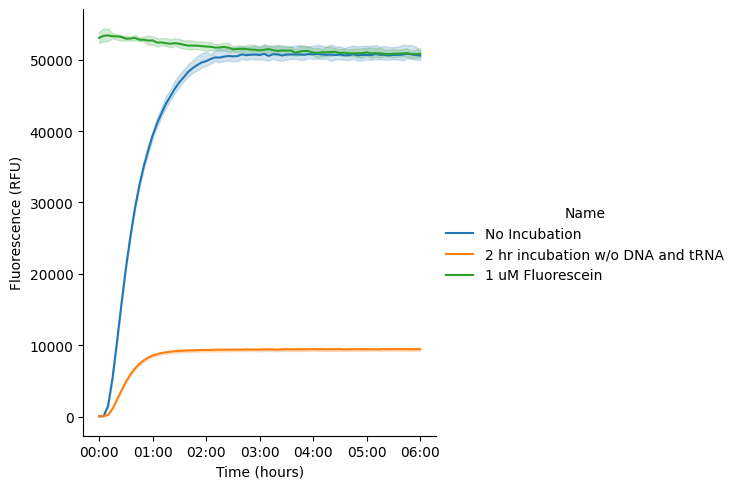

In [6]:
g = pr.plot_curves(data=data)
plt.savefig("kinetics")

## Normalize Data

In [7]:
data = pr.normalize_data_to_controls(data, ctrl_name = '1 uM Fluorescein')

Data Normalized to 1 uM Fluorescein in col data_normalized. The active column for subsequent operations is: data_normalized


Now replot your curves to see them normalized

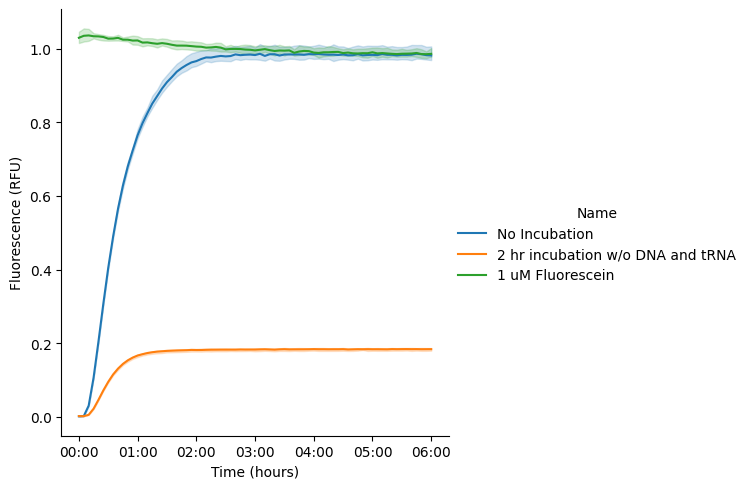

In [8]:
g = pr.plot_curves(data=data)
plt.savefig("kinetics-normalized")

## Kinetic Analysis
**Metrics extracted:**

  - **Vmax** (`Velocity Max`): Maximum rate of fluorescence increase (slope at inflection point)
  - **Lag time**: Time to reach the exponential phase
  - **Steady-state**: Final fluorescence level and time to reach 95% of asymptote
  - **Drift**: Rate of signal decay or increase after steady-state
  - **R²**: Goodness of fit

In [9]:
# Perform kinetic analysis using sigmoid_drift model
kinetics = pr.kinetic_analysis(
    data=data,
    group_by=['Well','Name'],  # Group by experimental condition
)

kinetics.head()

Calculating Kinetics


Velocity  \
                                                           Time   
Well Name                                                         
B2   No Incubation                    0 days 00:34:18.353546007   
B4   No Incubation                    0 days 00:34:03.535683884   
B6   No Incubation                    0 days 00:33:50.967618512   
D2   2 hr incubation w/o DNA and tRNA 0 days 00:29:36.272727351   
D4   2 hr incubation w/o DNA and tRNA 0 days 00:29:08.634550034   

                                                            \
                                      data_normalized  Max   
Well Name                                                    
B2   No Incubation                               0.52 1.04   
B4   No Incubation                               0.49 1.00   
B6   No Incubation                               0.50 1.00   
D2   2 hr incubation w/o DNA and tRNA            0.09 0.28   
D4   2 hr incubation w/o DNA and tRNA            0.09 0.28   

                                                            Lag  \
                                                           Time   
Well Name                                                         
B2   No Incubation                    0 days 00:04:29.068909449   
B4   No Incubation                    0 days 00:04:38.517100280   
B6   No Incubation                    0 days 00:04:08.775329401   
D2   2 hr incubation w/o DNA and tRNA 0 days 00:09:21.994364260   
D4   2 hr incubation w/o DNA and tRNA 0 days 00:09:33.561874227   

                                                       \
                                      data_normalized   
Well Name                                               
B2   No Incubation                               0.04   
B4   No Incubation                               0.05   
B6   No Incubation                               0.04   
D2   2 hr incubation w/o DNA and tRNA            0.02   
D4   2 hr incubation w/o DNA and tRNA            0.02   

                                                   Steady State  \
                                                           Time   
Well Name                                                         
B2   No Incubation                    0 days 01:18:12.573260344   
B4   No Incubation                    0 days 01:17:22.030440838   
B6   No Incubation                    0 days 01:17:34.745839969   
D2   2 hr incubation w/o DNA and tRNA 0 days 00:59:23.956998756   
D4   2 hr incubation w/o DNA and tRNA 0 days 00:57:58.599444981   

                                                       \
                                      data_normalized   
Well Name                                               
B2   No Incubation                               0.98   
B4   No Incubation                               0.93   
B6   No Incubation                               0.94   
D2   2 hr incubation w/o DNA and tRNA            0.18   
D4   2 hr incubation w/o DNA and tRNA            0.18   

                                                                                     Fit  \
                                                                                  params   
Well Name                                                                                  
B2   No Incubation                     [1.0305035716730582, 4.023954519549294, 0.5717...   
B4   No Incubation                     [0.983889146181609, 4.079277164836583, 0.56764...   
B6   No Incubation                     [0.9936540006235877, 4.039968103364663, 0.5641...   
D2   2 hr incubation w/o DNA and tRNA  [0.1861576266006079, 5.929447662855712, 0.4934...   
D4   2 hr incubation w/o DNA and tRNA  [0.1846920592741845, 6.127280591624355, 0.4857...   

                                                           
                                       R^2 drift good_fit  
Well Name                                                  
B2   No Incubation                    0.99  0.01     True  
B4   No Incubation                    0.99  0.01     Tru

## Visualize Fits on Individual Wells

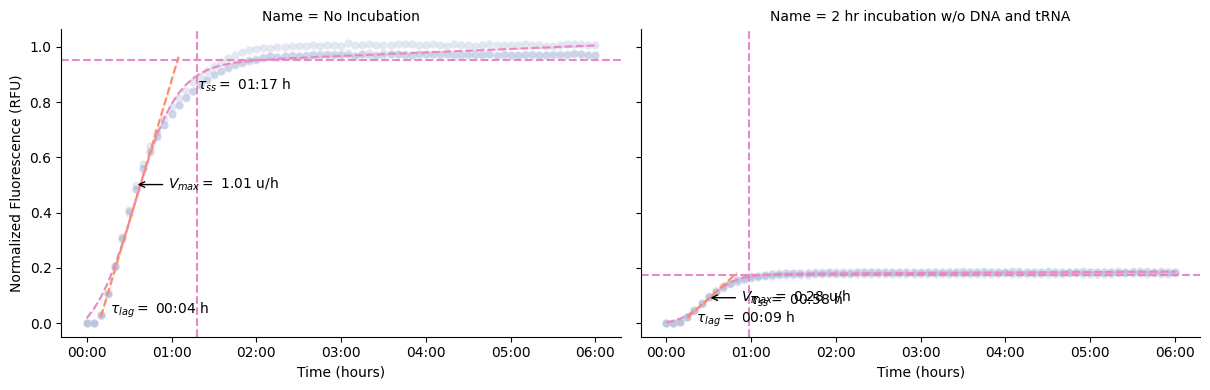

In [10]:
# Plot kinetic fits 
g = pr.plot_kinetics(data, kinetics=kinetics)

## Summary Plots

Calculating Kinetics


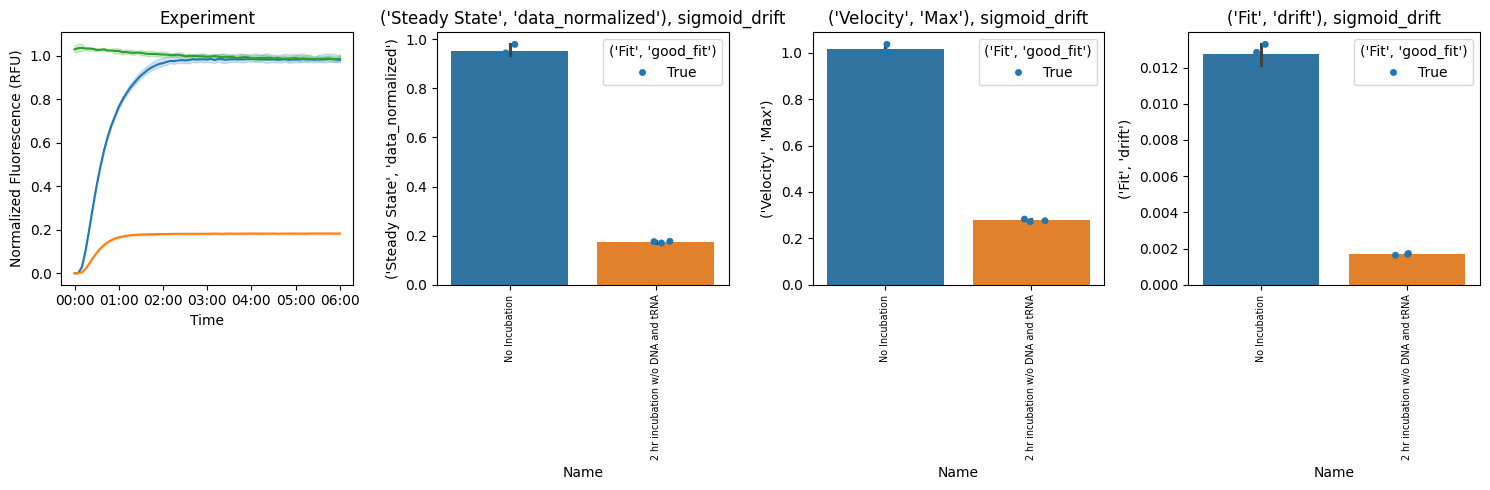

In [11]:
g = pr.plot_summary(data)
# g.savefig("summary.png", dpi=300)
plt.savefig("summary")

---

## Key Metrics Explained

### 1. **Steady-State Level** (`Steady State, Data`)
- The final fluorescence value reached by the reaction
- Represents the total amount of protein produced
- Higher values indicate greater expression yield

### 2. **Maximum Velocity** (`Velocity, Max`)
- The steepest slope of the fluorescence curve (at the inflection point)
- Units: RFU per second
- Reflects the peak rate of protein synthesis
- Sensitive to enzyme activity, substrate availability, and reaction conditions

### 3. **Lag Time** (`Lag, Time`)
- Time before exponential fluorescence increase begins
- May reflect time for ribosome assembly or initial translation steps
- Shorter lag times suggest faster reaction initiation

### 4. **Drift** (`Fit, drift`)
- Rate of fluorescence change after reaching steady-state
- Positive drift: continued synthesis or aggregation
- Negative drift: photobleaching, protein degradation, or quenching
- Units: RFU per second

### 5. **R² Value** (`Fit, R^2`)
- Goodness of fit (0 to 1, higher is better)
- R² > 0.98 indicates excellent fit
- Poor fits may indicate noisy data, overflow errors, or non-sigmoid kinetics

---

## Tips and Troubleshooting

- **Overflow errors:** Wells with `OVRFLW` or `NaN` values are automatically excluded from fitting
- **Poor fits (low R²):** Inspect raw curves for anomalies (bubbles, evaporation, pipetting errors)
- **Drift:** Sometimes seen in kinetics curves; use `sigmoid_drift` model
- **Multiple replicates:** Always include technical replicates and report error bars
- **Comparing conditions:** Normalize or blank data consistently across all samples

---

## Next Steps

- Export kinetics results: `pr.export_kinetics(kinetics, 'results.csv')`
- Statistical analysis: Use `scipy.stats` or `statsmodels` for ANOVA/t-tests
- Parameter optimization: Vary Mg²⁺, K⁺, or other conditions to maximize Vmax or steady-state
- Mechanistic modeling: Fit ODE models to extract biological rate constants